# A loss-of-flow transient

Four plate channels sit between an upper and a lower plenum: three with fuel plates (hot, warm, wide) and an unheated bypass. A pump drives water down through them. A flywheel stretches its coastdown, and a flapper valve in a parallel leg stays shut while the pump runs.

The pump trips and the reactor scrams. Flow coasts down until the flapper opens, and later buoyancy turns the heated channels upward into natural circulation. The geometry is MTR-like: plates 0.7 m long and 70 mm wide, gaps of 2 to 4 mm, about 117 kW before the scram.

In [1]:
%matplotlib inline
import sys
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import SVG
from scipy.optimize import brentq

from stream.calculations import (Channel, ChannelAndContacts, Flapper, Fuel, Gravity, HeatExchanger, Inertia,
                                 Junction, KirchhoffWDerivatives, Pump, Resistor, SaturationReachedError, Solid)
from stream.calculations.flapper import continuously_differentiable_relaxation
from stream.composition import (FlowGraph, check_gravity_mismatch, flow_edge, guess_steady_state, seed_steady_state,
                                symmetric_plate, uniform_x_power_shape, x_boundaries)
from stream.jacobians import ALG_jacobian, DAE_jacobian
from stream.physical_models.heat_transfer_coefficient import wall_heat_transfer_coeff
from stream.physical_models.pressure_drop import pressure_diff
from stream.physical_models.pressure_drop.friction import (friction_factor, rectangular_laminar_correction,
                                                           regime_dependent_friction)
from stream.pipe_geometry import EffectivePipe
from stream.substances import light_water
from stream.utilities import identity

sys.path.insert(0, str(Path.cwd().parent))
from showcase import lofa_case, plots
from showcase.lofa_case import CHANNELS, HEATED, Params

## The loop

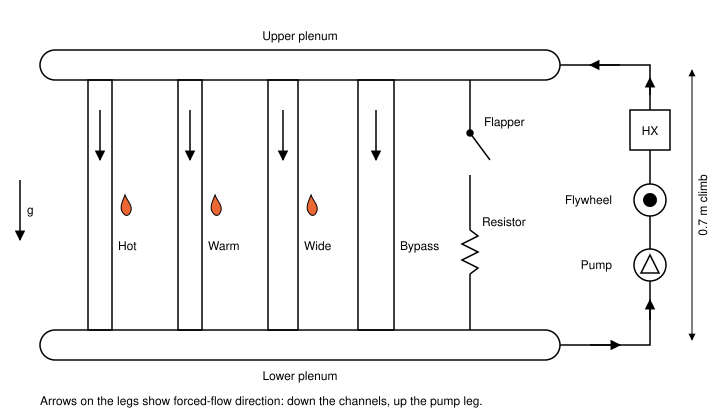

In [2]:
SVG("loop.svg")

## Building it

The cells below spell out `lofa_case.build`. First the operating point and the plena.

In [3]:
TIN, P_REF, DP0, G = 40.0, 2e5, 35e3, 9.80665
LENGTH, WIDTH, Z_N = 0.7, 0.070, 10
GAPS = dict(hot=0.002, warm=0.002, wide=0.003, bypass=0.004)
POWERS = dict(hot=0.7 * 84e3, warm=0.7 * 33.6e3, wide=0.7 * 50e3)
Z = np.linspace(0.0, LENGTH, Z_N + 1)
j_top, j_bot = Junction(name="J_top"), Junction(name="J_bot")

Heated channels are `ChannelAndContacts`: 1-D coolant columns with a plate on each face, set to stop the solve if the bulk saturates. `EffectivePipe.rectangular` gives area and hydraulic diameter. Friction is swapped for a laminar-to-turbulent law with the rectangular-duct correction, since the coastdown ends deep in laminar flow.

In [4]:
def pipe(gap):
    return EffectivePipe.rectangular(length=LENGTH, edge1=WIDTH, edge2=gap, heated_edge=WIDTH)


def regime_friction(channel, gap):
    k_R = float(rectangular_laminar_correction(gap / WIDTH))
    f = friction_factor("regime_dependent", re_bounds=(2000.0, 5000.0), k_R=k_R)
    channel.pressure = partial(pressure_diff, fluid=channel.fluid, pipe=channel.pipe, dz=channel.dz, f=f)


channels = {k: ChannelAndContacts(z_boundaries=Z, fluid=light_water, pipe=pipe(GAPS[k]),
                                  h_wall_func=wall_heat_transfer_coeff, stop_at_saturation=True,
                                  name=f"{k.capitalize()}Channel")
            for k in HEATED}
channels["bypass"] = Channel(z_boundaries=Z, fluid=light_water, pipe=pipe(GAPS["bypass"]), name="Bypass")
for k, ch in channels.items():
    regime_friction(ch, GAPS[k])

The flapper leg: `Flapper` opens below 30 % of the nominal pump-leg flow, estimated from the head and the gaps; `Gravity` carries its water column, and a `Resistor` closes the leg.

In [5]:
weights = {k: pipe(g).area * np.sqrt(pipe(g).hydraulic_diameter) for k, g in GAPS.items()}
mdot_nominal = sum(0.5 * w / weights["hot"] for w in weights.values())
flapper = Flapper(open_at_current=0.3 * mdot_nominal, f=5.0, fluid=light_water, area=1e-3, open_rate=1.0,
                  stop_on_open=False, relaxation=continuously_differentiable_relaxation, name="Flapper")
gravity_flap = Gravity(fluid=light_water, disposition=LENGTH, name="GravityFlapper")
resist_flap = Resistor(resistance=10.0, name="ResistFlap")

The pump leg: `Pump` imposes the head, `Inertia` is the flywheel, `HeatExchanger` resets the water to 40 °C, and `Gravity` charges the climb.

In [6]:
pump = Pump(pressure=DP0, name="Pump")
flywheel = Inertia(inertia=3e5, name="Flywheel")
hx = HeatExchanger(outlet=TIN, name="HX")
gravity_ret = Gravity(fluid=light_water, disposition=-LENGTH, name="GravityReturn")

`FlowGraph` turns one `flow_edge` per leg into the Kirchhoff network, mass balance at the plena and momentum around each loop. `check_gravity_mismatch` confirms every loop closes hydrostatically at zero flow.

In [7]:
fg = FlowGraph(
    *(flow_edge((j_top, j_bot), channels[k]) for k in CHANNELS),
    flow_edge((j_top, j_bot), flapper, gravity_flap, resist_flap),
    flow_edge((j_bot, j_top), pump, flywheel, hx, gravity_ret, ref_mdot_for=(flapper,)),
    inertial_comps=[flywheel, *channels.values()],
    k_constructor=KirchhoffWDerivatives,
    abs_pressure_comps=[channels[k] for k in HEATED],
    funcs={flapper: {"t": identity}},
    reference_node=(j_top, P_REF),
)
K = fg.kirchhoff
check_gravity_mismatch(K)

Each plate is a 2-D conduction grid, 10 axial cells by 12 across. `symmetric_plate` couples it to its channel on both faces and returns an aggregator that adds onto the hydraulic one.

In [8]:
CLAD_N, FUEL_N, CLAD_W, MEAT_W = 2, 8, 0.0005, 0.0006
CLADDING = Solid(density=2700, specific_heat=900, conductivity=167)
FUEL_MEAT = Solid(density=3500, specific_heat=750, conductivity=40)


def plate(name):
    meat = np.zeros((Z_N, FUEL_N + 2 * CLAD_N), dtype=bool)
    meat[:, CLAD_N:-CLAD_N] = True
    materials = np.where(meat, FUEL_MEAT, CLADDING)
    return Fuel(z_boundaries=Z, x_boundaries=x_boundaries(CLAD_N, FUEL_N, CLAD_W, MEAT_W),
                material=Solid.from_array(materials), meat_indices=meat,
                power_shape=uniform_x_power_shape(Z_N, FUEL_N, CLAD_N, CLAD_W, MEAT_W, WIDTH),
                y_length=WIDTH, name=f"{name.capitalize()}Fuel")


fuels = {k: plate(k) for k in HEATED}
agr = fg.aggregator
for k in HEATED:
    agr = agr + symmetric_plate(channels[k], fuels[k], funcs={fuels[k]: {"power": POWERS[k]}}).to_aggregator()

The state vector: per channel cell a coolant temperature and two heat-transfer coefficients, per plate cell a temperature, plus pressure drops, inlet temperatures and the Kirchhoff flows with their derivatives.

In [9]:
sizes = pd.Series({n.name: agr.sections[n].stop - agr.sections[n].start for n in agr.graph})
print(f"len(agr) = {len(agr)}")
print(sizes.to_string())

len(agr) = 555
J_top               1
HotChannel         31
J_bot               1
WarmChannel        31
WideChannel        31
Bypass             11
Flapper             2
GravityFlapper      2
ResistFlap          2
Pump                2
Flywheel            2
HX                  2
GravityReturn       2
Kirchhoff          15
HotFuel           140
WarmFuel          140
WideFuel          140


In [10]:
ref_agr, ref_K, ref = lofa_case.build(Params())
assert len(ref_agr) == len(agr) and np.isclose(ref["mdot_nominal"], mdot_nominal)

## Steady state

`guess_steady_state` seeds everything from one hint, the nominal pump-leg flow, then solves the thermal and hydraulic blocks in turn. Residual norm before and after:

In [11]:
hint = {pump: mdot_nominal}
seed = seed_steady_state(agr, K, flows=hint)
guess = guess_steady_state(agr, K, flows=hint)
for label, state in (("seed", seed), ("refined", guess)):
    print(f"{label:8s} |F| = {np.linalg.norm(agr.compute(agr.load(state), 0.0)):.3g}")
print(guess_steady_state.__doc__.splitlines()[0])

seed     |F| = 7.42e+04
refined  |F| = 10.8
A steady-state guess for a flow network wall-coupled to fuel plates.


In [12]:
y_steady = agr.solve_steady(agr.load(guess), jac=ALG_jacobian(agr))
print(f"|F| at the steady state = {np.linalg.norm(agr.compute(y_steady, 0.0)):.2g}")

|F| at the steady state = 3e-10


Outlets against `Tin + P/(ṁ cp)`, and the split against Blasius friction at a shared head, `ṁ ∝ gap^(12/7)` for a thin slot.

In [13]:
st = agr.save(y_steady)
mdot = {k: float(st[K.name][K.component_edge(channels[k])]) for k in CHANNELS}
rows = []
for k in CHANNELS:
    T_out = float(np.asarray(st[channels[k].name]["T_cool"])[-1])
    cp = light_water.specific_heat(0.5 * (TIN + T_out))
    rows.append(dict(channel=k, mdot=mdot[k], T_out=T_out, T_out_hand=TIN + POWERS.get(k, 0.0) / (mdot[k] * cp),
                     split=mdot[k] / mdot["hot"], split_hand=(GAPS[k] / GAPS["hot"]) ** (12 / 7)))
pd.DataFrame(rows).set_index("channel").round(3)

,mdot,T_out,T_out_hand,split,split_hand
channel,,,,,
hot,0.539,66.072,66.075,1.000,1.000
warm,0.530,50.606,50.606,0.984,1.000
wide,1.048,47.988,47.988,1.944,2.004
bypass,1.679,40.000,40.000,3.113,3.281


In [14]:
ref_st = ref_agr.save(lofa_case.steady(ref_agr, lofa_case.guess(ref_agr, ref_K, ref, "toolkit")))
ref_mdot = [ref_st[ref_K.name][ref_K.component_edge(ref["channels"][k])] for k in CHANNELS]
assert np.allclose(ref_mdot, [mdot[k] for k in CHANNELS], rtol=1e-6)

## The transient

`scram` ramps the pump head to zero along a half cosine between 3 and 3.5 s. Over the same half second each plate's power blends into decay heat, 6.6 % of the plate's operating (derated) power before the scram, not of full power, falling as `t^-0.2`.

In [15]:
handles = dict(channels=channels, fuels=fuels, flapper=flapper, pump=pump)
lofa_case.scram(agr, handles, Params())

IDA integrates 2500 s, each variable's absolute tolerance scaled to its own magnitude by `scaled_atol`.

In [16]:
sol = agr.solve(y_steady, time=np.linspace(0.0, 2500.0, 5001), jacfn=DAE_jacobian(agr),
                atol=agr.scaled_atol(1e-4), rtol=1e-4, max_steps=1_000_000)
print("status:", sol.status.name)
print("events:", sol.events)
print(f"flapper.t_open = {flapper.t_open:.1f} s")

status: COMPLETED
events: (Event(t=77.93543650523172, stopped=(), terminal=False),)
flapper.t_open = 77.9 s


## What happened

Left, the whole run; right, the channels near zero flow. Hot, warm and wide reverse in that order while the bypass keeps flowing down.

{'hot': 814.0, 'warm': 1169.5, 'wide': 1499.0, 'bypass': None}


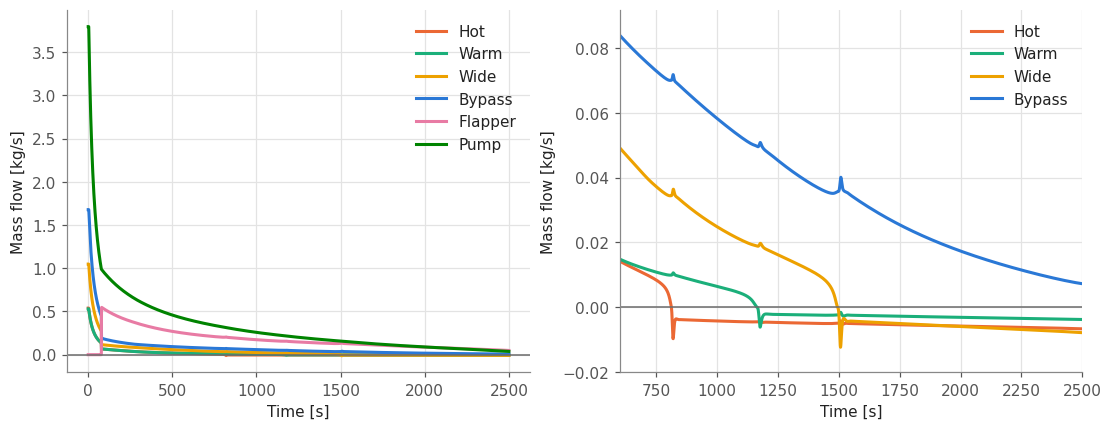

In [17]:
df = lofa_case.flows(agr, K, handles, sol)
rev = lofa_case.reversal_times(df)
with plots.style():
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), layout="constrained")
    plots.flows(df, ax=axes[0])
    plots.flows(df, ax=axes[1], zoom=(600, 2500), legs=CHANNELS)
print({k: v for k, v in rev.items()})

By 2500 s the loop runs on natural circulation: the heated channels rise, the bypass and flapper leg carry the water back down, and the pump leg keeps a small upward flow through the HX.

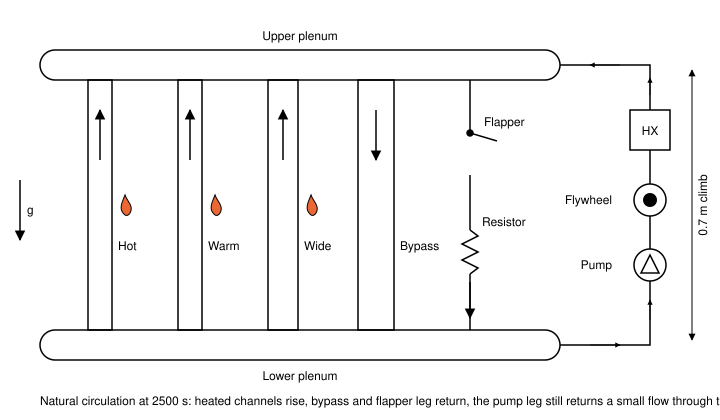

In [18]:
SVG("loop-nc.svg")

### Why the other legs twitch at each reversal

The legs' flows sum exactly at each plenum, so when the hot channel swings about 0.014 kg/s below its trend the others absorb it in proportion to how easily they pass flow: the flapper leg about 0.006, the bypass and wide channel about 0.003 each.

The overshoot is buoyancy starting up. As the flow decays the column heats and its buoyancy `g L (ρ_cold − ρ_column)` climbs from about 26 Pa toward the head the plena offer, about 102 Pa. Flow reverses once buoyancy passes it. The hot plug keeps heating as it rises, so buoyancy peaks near 162 Pa some seven seconds later, with the upward flow. Cold inflow then flushes the column within one transit time and the flow settles near 0.0042 kg/s. A coarse output grid draws this ten-second hump as a kink.

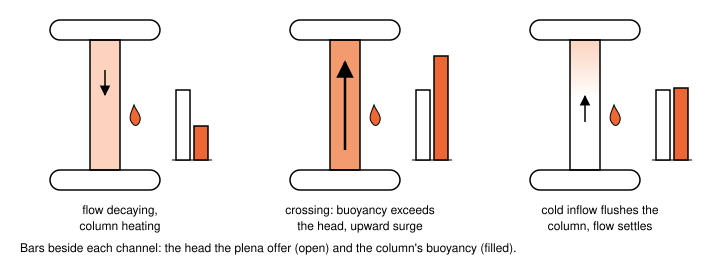

In [19]:
SVG("reversal.svg")

t0 = 812.5 s; peak upward 0.0098 kg/s at t0 + 7.5 s; settled 0.0042 kg/s at t0 + 150 s; buoyancy 26 Pa at t0 - 200 s, 105 Pa at t0, peak 162 Pa at t0 + 6.5 s; plena head 102 Pa
t0 + 7.0 s: hot -0.0140 off trend; warm +0.0010 wide +0.0027 bypass +0.0030 flapper +0.0062 pump -0.0010


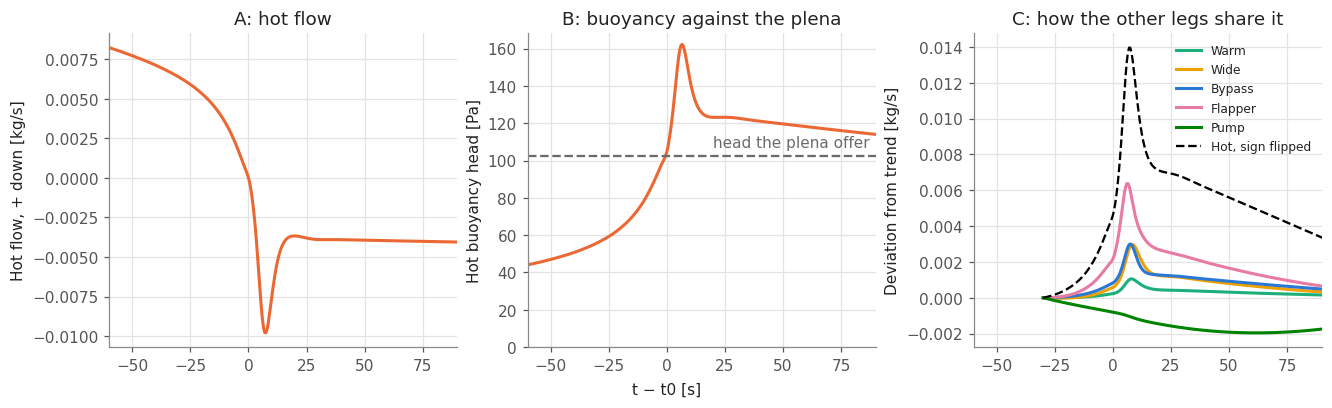

In [20]:
i0 = int(np.flatnonzero(df["hot"].to_numpy() < 0)[0])
s, m = df["t"].to_numpy() - df["t"][i0], df["hot"].to_numpy()
rho_cold = light_water.density(agr.at_times(sol, j_bot, "Tin"))
buoy = G * LENGTH * (rho_cold - light_water.density(agr.at_times(sol, channels["hot"], "T_cool")).mean(axis=1))
head = rho_cold[i0] * G * LENGTH - agr.at_times(sol, channels["hot"], "pressure")[i0]
w, view = (s >= -30) & (s <= 150), (s >= -60) & (s <= 90)
dev = {k: df[k][w].to_numpy() - np.interp(s[w], s[w][[0, -1]], df[k][w].to_numpy()[[0, -1]]) for k in plots.LEGS}
j, k_pk, k_b = np.argmin(dev["hot"]), i0 + np.argmin(m[i0:i0 + 120]), i0 + np.argmax(buoy[i0:i0 + 120])
with plots.style():
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, layout="constrained")
    axes[0].plot(s[view], m[view], color=plots.COLORS["hot"])
    axes[1].plot(s[view], buoy[view], color=plots.COLORS["hot"])
    plots.hline(axes[1], head, "head the plena offer")
    for k in plots.LEGS[1:]:
        axes[2].plot(s[w], dev[k], color=plots.COLORS[k], label=k.capitalize())
    axes[2].plot(s[w], -dev["hot"], color="black", linestyle="--", linewidth=1.5, label="Hot, sign flipped")
    axes[2].legend(fontsize=8)
    axes[0].set(xlim=(-60, 90), ylabel="Hot flow, + down [kg/s]", title="A: hot flow")
    axes[1].set(ylabel="Hot buoyancy head [Pa]", ylim=(0, None), title="B: buoyancy against the plena")
    axes[2].set(ylabel="Deviation from trend [kg/s]", title="C: how the other legs share it")
    fig.supxlabel("t − t0 [s]", fontsize=10)
print(f"t0 = {df['t'][i0]:.1f} s; peak upward {-m[k_pk]:.4f} kg/s at t0 + {s[k_pk]:.1f} s; settled {-m[i0 + 300]:.4f}"
      f" kg/s at t0 + {s[i0 + 300]:.0f} s; buoyancy {buoy[i0 - 400]:.0f} Pa at t0 - 200 s, {buoy[i0]:.0f} Pa at t0,"
      f" peak {buoy[k_b]:.0f} Pa at t0 + {s[k_b]:.1f} s; plena head {head:.0f} Pa")
print(f"t0 + {s[w][j]:.1f} s: hot {dev['hot'][j]:+.4f} off trend;", *(f"{k} {dev[k][j]:+.4f}" for k in plots.LEGS[1:]))

Panel B shows buoyancy crossing the head the plena offer at the moment of reversal and peaking with the upward flow; in panel C the four downward legs' deviations, less the pump leg's dip, add up to the hot channel's own.

The hot channel peaks at about 108 °C, about 12 °C below saturation, at about 820 s: some 8 s after its flow passes closest to zero.

hot peak 107.9 °C at t = 820 s, margin 12.4 °C
hot-channel flow closest to zero at t = 812 s


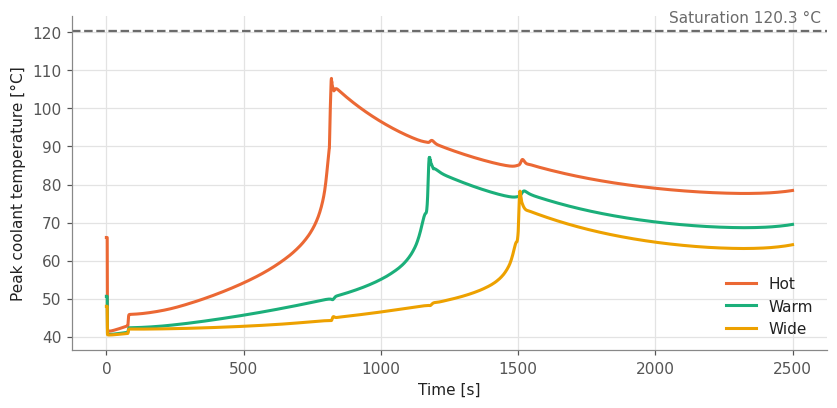

In [21]:
TSAT = lofa_case.TSAT(P_REF)
peaks = lofa_case.peak_series(agr, handles, sol)
with plots.style():
    fig = plots.peaks(peaks, TSAT)
t_peak = float(peaks["t"][peaks["hot"].idxmax()])
t_zero = float(df["t"][df["hot"].abs().idxmin()])
print(f"hot peak {peaks['hot'].max():.1f} °C at t = {t_peak:.0f} s, margin {TSAT - peaks['hot'].max():.1f} °C")
print(f"hot-channel flow closest to zero at t = {t_zero:.0f} s")

Hot-channel coolant and wall before the scram, mid-coastdown, reversal and the end; height from the plate bottom.

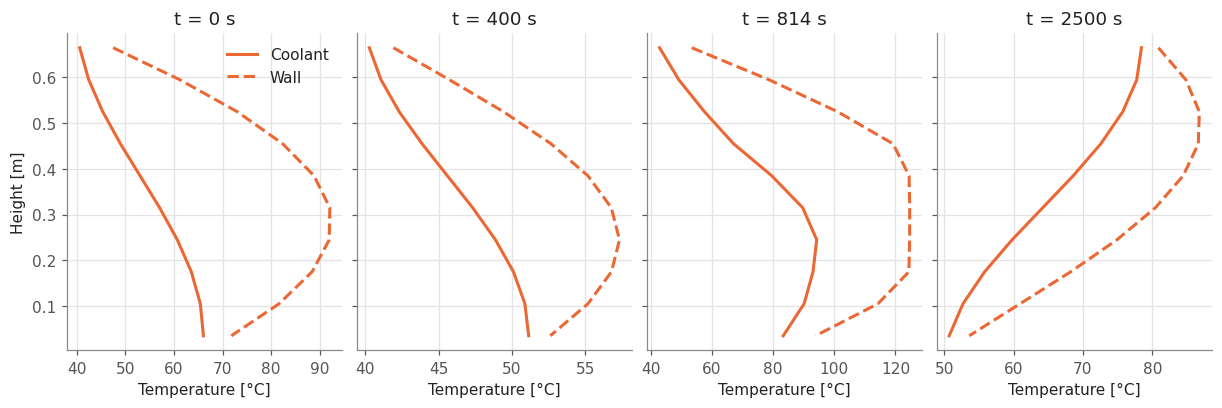

In [22]:
t, T_cool, T_wall = lofa_case.temperatures(agr, handles, sol, "hot")
height = LENGTH - 0.5 * (Z[1:] + Z[:-1])
with plots.style():
    fig, axes = plt.subplots(1, 4, figsize=(11, 3.6), sharey=True, layout="constrained")
    for ax, when in zip(axes, (0.0, 400.0, rev["hot"], 2500.0)):
        i = int(np.argmin(np.abs(t - when)))
        plots.profile(height, T_cool[i], T_wall[i], ax=ax, title=f"t = {t[i]:.0f} s", legend=ax is axes[0])
    for ax in axes[1:]:
        ax.set_ylabel("")

The imposed pump head is gone by 3.5 s. The hot channel's pressure difference moves from about −28 kPa to the weight of its water column, `ρ g L`.

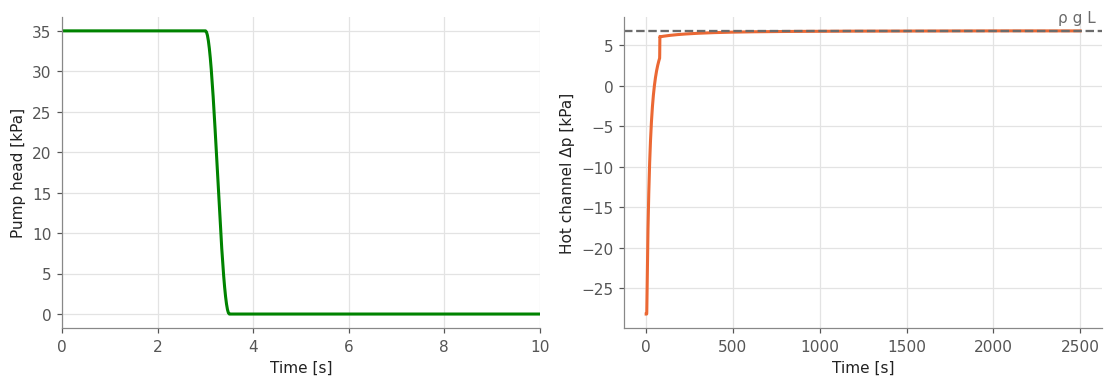

In [23]:
t_fine = np.linspace(0.0, 10.0, 501)
p_pump = np.array([agr.funcs[pump]["pressure"](x) for x in t_fine]) / 1e3
dp_hot = agr.at_times(sol, channels["hot"], "pressure") / 1e3
rho_gL = float(np.mean(light_water.density(T_cool[-1]))) * G * LENGTH / 1e3
with plots.style():
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), layout="constrained")
    axes[0].plot(t_fine, p_pump, color=plots.COLORS["pump"])
    axes[0].set(xlim=(0, 10), xlabel="Time [s]", ylabel="Pump head [kPa]")
    axes[1].plot(t, dp_hot, color=plots.COLORS["hot"])
    plots.hline(axes[1], rho_gL, "ρ g L")
    axes[1].set(xlabel="Time [s]", ylabel="Hot channel Δp [kPa]")

The events on one time line.

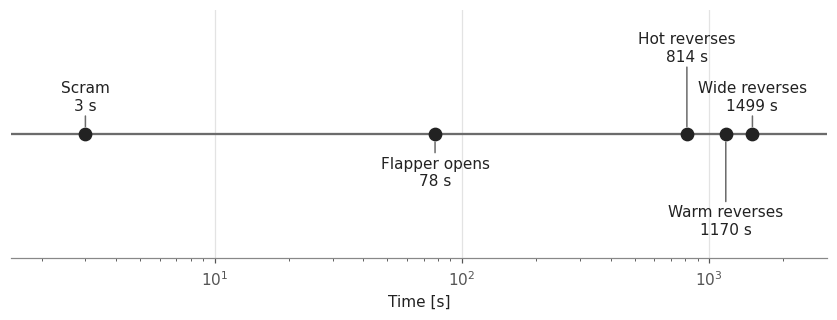

In [24]:
events = {"Scram": 3.0, "Flapper opens": flapper.t_open}
events |= {f"{k.capitalize()} reverses": rev[k] for k in HEATED}
with plots.style():
    fig = plots.schedule(events)

## Hand checks

Each line prints model / hand / ratio. The opening time integrates the coastdown `L dṁ/dt = −K ṁ^n` from mid-ramp, once with the Blasius `n = 1.75` and once with the cruder `n = 2`.

In [25]:
def check(name, model, hand):
    print(f"{name:34s} {model:10.4g} / {hand:10.4g} / {model / hand:6.3f}")


m0, m_th, L, t0 = df["pump"].iloc[0], 0.3 * mdot_nominal, 3e5, 3.25
t_175 = t0 + L / (0.75 * DP0 / m0 ** 1.75 * m0 ** 0.75) * ((m0 / m_th) ** 0.75 - 1)
t_2 = t0 + L / (DP0 / m0 ** 2 * m0) * (m0 / m_th - 1)
check("flapper opening, n = 1.75 [s]", flapper.t_open, t_175)
check("flapper opening, n = 2 [s]", flapper.t_open, t_2)

i0 = int(np.argmin(np.abs(df["hot"].to_numpy())))
check(f"hot Δp at zero flow, t={t[i0]:.0f} s [Pa]", 1e3 * dp_hot[i0],
      float(np.mean(light_water.density(T_cool[i0]))) * G * LENGTH)

flapper opening, n = 1.75 [s]           77.94 /      78.57 /  0.992
flapper opening, n = 2 [s]              77.94 /      95.24 /  0.818
hot Δp at zero flow, t=812 s [Pa]        6701 /       6698 /  1.000


Natural circulation. Buoyancy `g L (ρ_cold − ρ_hot)` against the hot channel's own friction law gives a flow; a second balance takes off what the rest of the loop costs, the measured shortfall of the plena pressure difference below the cold column's weight. The outlet follows from the lower plenum plus decay heat over `|ṁ| cp`.

In [26]:
T_top, T_bot = agr.at_times(sol, j_top, "Tin"), agr.at_times(sol, j_bot, "Tin")
hot_pipe, k_R = channels["hot"].pipe, float(rectangular_laminar_correction(GAPS["hot"] / WIDTH))


def nc_flow(i, shortfall):
    T_mean, rho_hot = float(T_cool[i].mean()), float(np.mean(light_water.density(T_cool[i])))
    drive = G * LENGTH * (float(light_water.density(T_top[i])) - rho_hot) - shortfall

    def excess(m):
        f = regime_dependent_friction(T_mean, T_mean, m, light_water, hot_pipe, (2000.0, 5000.0), k_R)
        return f * LENGTH / hot_pipe.hydraulic_diameter * m ** 2 / (2 * rho_hot * hot_pipe.area ** 2) - drive
    return brentq(excess, 1e-6, 1.0)


for when in (2000.0, 2500.0):
    i = int(np.argmin(np.abs(t - when)))
    short = float(light_water.density(T_top[i])) * G * LENGTH - 1e3 * dp_hot[i]
    print(f"t = {t[i]:.0f} s: plena shortfall {short:.1f} Pa, pump-leg flow {df['pump'][i]:.3f} kg/s")
    check("  hot NC flow, buoyancy only", abs(df["hot"][i]), nc_flow(i, 0.0))
    check("  hot NC flow, less shortfall", abs(df["hot"][i]), nc_flow(i, short))
P_decay = POWERS["hot"] * 0.066 * (t[-1] - 3.0 + 0.1) ** -0.2
cp_hot = light_water.specific_heat(float(T_cool[-1].mean()))
check("hot NC outlet at 2500 s [°C]", T_cool[-1][0], T_bot[-1] + P_decay / (abs(df["hot"].iloc[-1]) * cp_hot))

t = 2000 s: plena shortfall 20.0 Pa, pump-leg flow 0.089 kg/s
  hot NC flow, buoyancy only         0.005902 /   0.008985 /  0.657
  hot NC flow, less shortfall        0.005902 /    0.00606 /  0.974
t = 2500 s: plena shortfall 6.6 Pa, pump-leg flow 0.037 kg/s
  hot NC flow, buoyancy only         0.006746 /   0.007857 /  0.859
  hot NC flow, less shortfall        0.006746 /   0.006864 /  0.983
hot NC outlet at 2500 s [°C]            78.44 /      78.79 /  0.996


The opening time lands within about 1 % of the Blasius coastdown; the quadratic law runs about 20 % late.

On buoyancy alone the balance overshoots: the model's hot-channel flow is about two thirds of that estimate at 2000 s and about 86 % at 2500 s. The loop is not yet a pure natural-circulation loop. The pump leg still carries about 0.09 and then 0.04 kg/s, and the plena pressure difference sits about 20 and then 7 Pa below the cold column's weight. With that shortfall taken off, the channel's friction law matches the model to within about 3 %. That corrected balance re-checks the channel's own momentum equation with a measured input, so it is not an independent prediction; the buoyancy-only numbers are the independent part.

Where the decay heat goes. The HX duty is the pump-leg flow times `cp` times the drop from the lower plenum (the pump and flywheel leave the temperature unchanged) to 40 °C, set against the decay heat of the three plates.

In [27]:
for when in (1000.0, 1500.0, 2000.0, 2500.0):
    i = int(np.argmin(np.abs(t - when)))
    duty = df["pump"][i] * light_water.specific_heat(T_bot[i]) * (T_bot[i] - TIN)
    decay = sum(POWERS.values()) * 0.066 * (t[i] - 3.0 + 0.1) ** -0.2
    print(f"t = {t[i]:4.0f} s: HX {duty / 1e3:5.2f} kW, decay {decay / 1e3:5.2f} kW,"
          f" upper plenum {T_top[i]:.1f} °C, lower plenum {T_bot[i]:.1f} °C")

t = 1000 s: HX  1.95 kW, decay  1.95 kW, upper plenum 40.9 °C, lower plenum 41.8 °C
t = 1500 s: HX  1.29 kW, decay  1.79 kW, upper plenum 42.0 °C, lower plenum 42.0 °C
t = 2000 s: HX  1.71 kW, decay  1.69 kW, upper plenum 44.6 °C, lower plenum 44.6 °C
t = 2500 s: HX  1.58 kW, decay  1.62 kW, upper plenum 50.1 °C, lower plenum 50.1 °C


The HX keeps pace with the decay heat, within a few percent except around 1500 s, where it falls about 30 % short. It manages because the plena warm: as the pump-leg flow coasts down, the temperature drop across the HX has to grow, and the plena climb from about 41 °C to about 50 °C.

## Where the model ends

Without the 0.7 derating the hot channel's bulk reaches saturation. STREAM models single-phase flow and subcooled boiling only, so the channel stops the solve and names itself.

In [28]:
p_full = Params(power_scale=1.0)
agr_f, K_f, ref_f = lofa_case.build(p_full)
y_f = lofa_case.steady(agr_f, lofa_case.guess(agr_f, K_f, ref_f, "toolkit"))
lofa_case.scram(agr_f, ref_f, p_full)
try:
    lofa_case.transient(agr_f, ref_f, y_f)
    print("completed without reaching saturation")
except SaturationReachedError as err:
    print(err)
    print(f"valid trajectory kept up to t = {err.t[-1]:.0f} s")
    T_bot_f = np.asarray(err.y)[:, agr_f.sections[next(n for n in agr_f.graph if n.name == "J_bot")]].ravel()
    t_f = np.asarray(err.t)
    print(f"lower plenum {T_bot_f[np.argmin(np.abs(t_f - 1000.0))]:.1f} °C at 1000 s, {T_bot_f[-1]:.1f} °C at the stop")

Channel 'HotChannel' reached saturation: bulk coolant in cell(s) [1] is at/above Tsat (worst cell 1: T_bulk=120.50°C >= Tsat=120.50°C). STREAM's single-phase model ends at bulk saturation — two-phase flow is not modelled — so the solve was stopped here. Reduce power, raise pressure, or increase flow to keep the channel subcooled.
valid trajectory kept up to t = 2414 s
lower plenum 42.5 °C at 1000 s, 84.3 °C at the stop


The stop comes at about 2400 s, long after the reversal peak. As in the derated run, the plena warm while the pump-leg flow coasts down: the lower plenum climbs from about 43 °C at 1000 s to about 84 °C at the stop, and a cell near the top of the hot channel reaches saturation.

## Further reading

`docs/source/failure_modes.md` explains each way a STREAM solve stops. The `stream.composition` and `stream.aggregator` API pages cover `FlowGraph`, the guess toolkit and `Aggregator.solve`.